# Multicollinearity Analysis — `factory_final.csv`

**Objective**: Identify and resolve multicollinearity among the 16 numerical features to improve linear model stability and feature selection.

**Findings from EDA (notebook 02)**:
- `Remaining_Lease_Years` and `Lease_Duration` are likely highly correlated with each other
- `Postal_District` and `Postal_Sector` likely redundant (sector is finer granularity of district)
- 8 macro features are quarterly aggregates — high intercorrelation risk
- `Month` and `Quarter` are functionally related

---

## Contents
1. Imports & Data Loading
2. Pearson Correlation Heatmap
3. High-Correlation Pair Extraction
4. VIF Analysis — All Features
5. Sub-Group Deep Dives
   - 5a. Lease Group
   - 5b. Location Group
   - 5c. Macro Group
   - 5d. Time Group
6. Iterative VIF Reduction
7. Summary & Recommendations

## 1. Imports & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("../data/processed/factory_final.csv")

TARGET = "Unit Price ($ psf)"

# NOTE: Year, Month, Quarter are excluded — mapping keys used solely to join
# macro indicators onto transactions, not predictive features.
# NOTE: Postal District and Postal Sector are excluded — they are numerical
# codes (identifiers), not true continuous variables. The observed correlation
# with price is a coincidence of how Singapore postal districts are numbered.
# Location is better captured by Region and Planning Area (proper categoricals).
FEATURE_COLS = [
    "Area (sqft)",
    "Lease_Duration", "Remaining_Lease_Years",
    "GDP_YoY_Growth_Rate", "CPI_All_Items", "Unemployment_Rate",
    "Price_Index", "10Y_Bond_Yield", "SORA_3M_Compounded",
    "Cement_Bulk_Per_Tonne", "Steel_Rebar_Per_Tonne"
]

print(f"Dataset shape: {df.shape}")
print(f"Features: {len(FEATURE_COLS)}")
print(f"Target: {TARGET}")
print(f"\nExcluded (mapping keys only): Year, Month, Quarter")
print(f"Excluded (numerical codes, not continuous): Postal District, Postal Sector")
print(f"Null counts in features: {df[FEATURE_COLS].isnull().sum().sum()} (total)")

Dataset shape: (3782, 25)
Features: 11
Target: Unit Price ($ psf)

Excluded (mapping keys only): Year, Month, Quarter
Excluded (numerical codes, not continuous): Postal District, Postal Sector
Null counts in features: 0 (total)


## 2. Pearson Correlation Heatmap

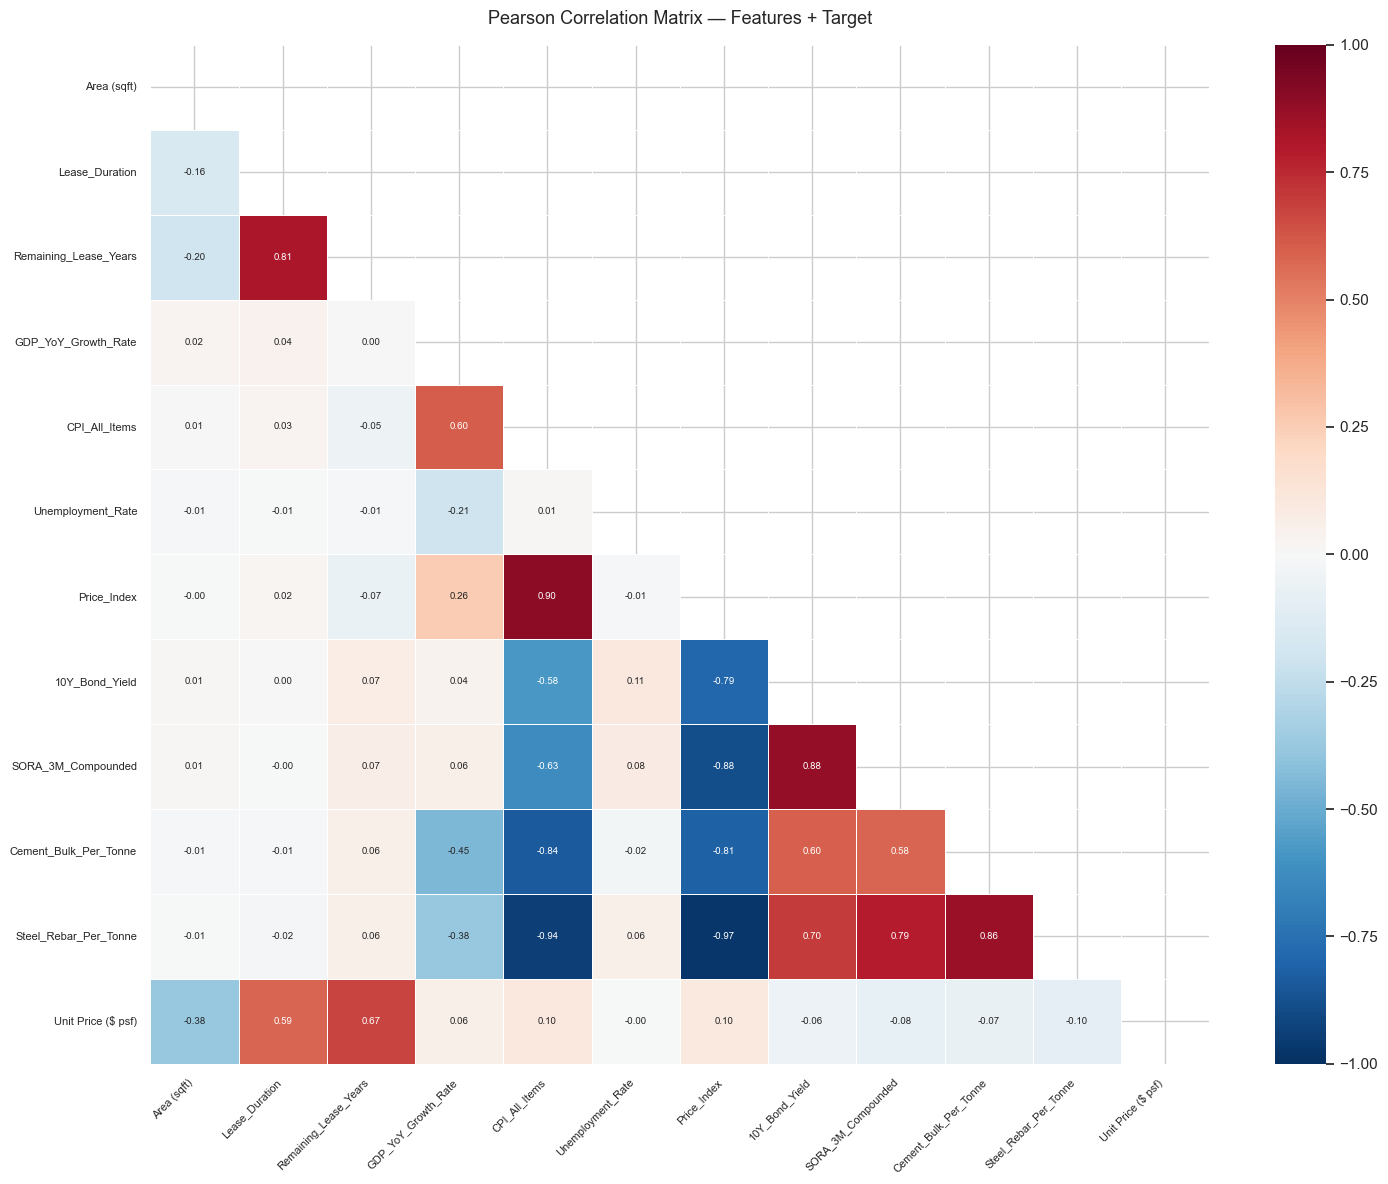

In [2]:
corr = df[FEATURE_COLS + [TARGET]].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(15, 12))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", vmin=-1, vmax=1,
    linewidths=0.4, linecolor="white",
    annot_kws={"size": 7}, ax=ax
)
ax.set_title("Pearson Correlation Matrix — Features + Target", fontsize=13, pad=15)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

## 3. High-Correlation Pair Extraction

In [3]:
feature_corr = df[FEATURE_COLS].corr()

# Extract upper triangle pairs only (exclude self-correlations)
pairs = []
for i in range(len(FEATURE_COLS)):
    for j in range(i + 1, len(FEATURE_COLS)):
        r = feature_corr.iloc[i, j]
        pairs.append({"Feature_1": FEATURE_COLS[i], "Feature_2": FEATURE_COLS[j], "Correlation": round(r, 3)})

pairs_df = pd.DataFrame(pairs).sort_values("Correlation", key=abs, ascending=False)

print("=== ACTION REQUIRED: |r| > 0.80 ===")
high = pairs_df[pairs_df["Correlation"].abs() > 0.80]
display(high.reset_index(drop=True))

print(f"\n=== WATCH LIST: 0.70 < |r| ≤ 0.80 ===")
watch = pairs_df[(pairs_df["Correlation"].abs() > 0.70) & (pairs_df["Correlation"].abs() <= 0.80)]
display(watch.reset_index(drop=True))

=== ACTION REQUIRED: |r| > 0.80 ===


,Feature_1,Feature_2,Correlation
0,Price_Index,Steel_Rebar_Per_Tonne,-0.971
1,CPI_All_Items,Steel_Rebar_Per_Tonne,-0.939
2,CPI_All_Items,Price_Index,0.896
3,Price_Index,SORA_3M_Compounded,-0.885
4,10Y_Bond_Yield,SORA_3M_Compounded,0.879
5,Cement_Bulk_Per_Tonne,Steel_Rebar_Per_Tonne,0.865
6,CPI_All_Items,Cement_Bulk_Per_Tonne,-0.841
7,Price_Index,Cement_Bulk_Per_Tonne,-0.815
8,Lease_Duration,Remaining_Lease_Years,0.813



=== WATCH LIST: 0.70 < |r| ≤ 0.80 ===


,Feature_1,Feature_2,Correlation
0,Price_Index,10Y_Bond_Yield,-0.792
1,SORA_3M_Compounded,Steel_Rebar_Per_Tonne,0.788
2,10Y_Bond_Yield,Steel_Rebar_Per_Tonne,0.703


## 4. VIF Analysis — All 11 Features

VIF measures how much variance of a coefficient is inflated due to collinearity with other features.

| VIF | Interpretation |
|-----|---------------|
| < 5 | OK — low collinearity |
| 5–10 | WATCH — moderate collinearity |
| > 10 | HIGH — problematic, consider removing |

> **Note**: `Year`, `Month`, `Quarter` are excluded — mapping keys only, not model features.
> `Postal District` and `Postal Sector` are excluded — numerical codes, not true continuous variables. Location is captured by `Region` and `Planning Area` (categorical features).

In [4]:
def compute_vif(feature_df):
    """Compute VIF for each feature in the DataFrame after standardising."""
    X = StandardScaler().fit_transform(feature_df)
    vif_vals = [variance_inflation_factor(X, i) for i in range(X.shape[1])]
    result = pd.DataFrame({
        "Feature": feature_df.columns,
        "VIF": np.round(vif_vals, 2)
    }).sort_values("VIF", ascending=False).reset_index(drop=True)
    result["Flag"] = result["VIF"].apply(
        lambda v: "HIGH" if v > 10 else ("WATCH" if v > 5 else "OK")
    )
    return result

vif_all = compute_vif(df[FEATURE_COLS].dropna())

# Colour-coded display
def highlight_vif(row):
    if row["Flag"] == "HIGH":
        return ["background-color: #ffcccc"] * len(row)
    elif row["Flag"] == "WATCH":
        return ["background-color: #fff3cc"] * len(row)
    return [""] * len(row)

print(f"VIF Analysis — {len(FEATURE_COLS)} features")
vif_all.style.apply(highlight_vif, axis=1)

VIF Analysis — 11 features


,Feature,VIF,Flag
0,Price_Index,88.140000,HIGH
1,Steel_Rebar_Per_Tonne,50.350000,HIGH
2,CPI_All_Items,45.870000,HIGH
3,SORA_3M_Compounded,19.530000,HIGH
4,GDP_YoY_Growth_Rate,6.970000,WATCH
5,Cement_Bulk_Per_Tonne,5.840000,WATCH
6,10Y_Bond_Yield,5.650000,WATCH
7,Remaining_Lease_Years,3.070000,OK
8,Lease_Duration,3.010000,OK
9,Unemployment_Rate,1.890000,OK


## 5. Sub-Group Deep Dives

### 5a. Lease Group — `Lease_Duration` vs `Remaining_Lease_Years`

Lease_Duration vs Remaining_Lease_Years:  r = 0.813
Lease_Duration vs Unit Price ($ psf):     r = 0.586
Remaining_Lease_Years vs Unit Price ($ psf): r = 0.672

Recommendation: Keep Remaining_Lease_Years (higher target correlation: 0.672 vs 0.586)


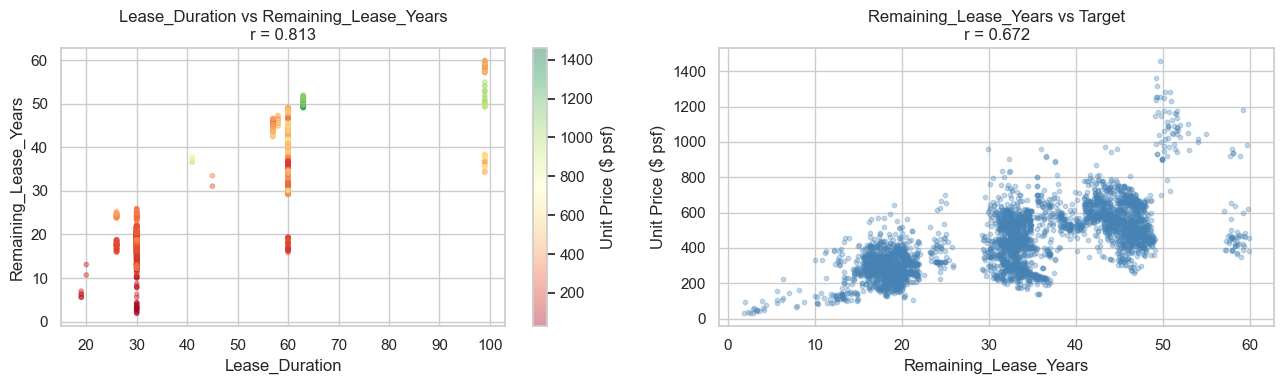

In [5]:
r_lease = df["Lease_Duration"].corr(df["Remaining_Lease_Years"])
r_ld_target = df["Lease_Duration"].corr(df[TARGET])
r_rl_target = df["Remaining_Lease_Years"].corr(df[TARGET])

print(f"Lease_Duration vs Remaining_Lease_Years:  r = {r_lease:.3f}")
print(f"Lease_Duration vs {TARGET}:     r = {r_ld_target:.3f}")
print(f"Remaining_Lease_Years vs {TARGET}: r = {r_rl_target:.3f}")
print(f"\nRecommendation: Keep Remaining_Lease_Years (higher target correlation: {r_rl_target:.3f} vs {r_ld_target:.3f})")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sc = axes[0].scatter(df["Lease_Duration"], df["Remaining_Lease_Years"],
                     c=df[TARGET], cmap="RdYlGn", alpha=0.4, s=10)
plt.colorbar(sc, ax=axes[0], label="Unit Price ($ psf)")
axes[0].set_xlabel("Lease_Duration")
axes[0].set_ylabel("Remaining_Lease_Years")
axes[0].set_title(f"Lease_Duration vs Remaining_Lease_Years\nr = {r_lease:.3f}")

axes[1].scatter(df["Remaining_Lease_Years"], df[TARGET], alpha=0.3, s=10, color="steelblue")
axes[1].set_xlabel("Remaining_Lease_Years")
axes[1].set_ylabel("Unit Price ($ psf)")
axes[1].set_title(f"Remaining_Lease_Years vs Target\nr = {r_rl_target:.3f}")

plt.tight_layout()
plt.show()

### 5b. Location Features — Excluded from Analysis

`Postal District` and `Postal Sector` are **not included as model features** for two reasons:

1. **They are numerical codes, not continuous variables** — the numbers carry no ordinal meaning. The observed correlation with price (r≈-0.38) is a coincidence of how Singapore postal districts are numbered, not a true linear relationship.

2. **They are redundant with proper location categoricals** — `Region` (5 categories) and `Planning Area` (24 areas) already capture location signal in a more interpretable and domain-appropriate form.

Both are dropped. Location is represented by `Region` and `Planning Area` in the final feature set.

In [6]:
print("Postal District and Postal Sector excluded from feature set.")
print("Reason 1: Numerical codes — not true continuous variables.")
print("Reason 2: Location already captured by Region and Planning Area (proper categoricals).")

Postal District and Postal Sector excluded from feature set.
Reason 1: Numerical codes — not true continuous variables.
Reason 2: Location already captured by Region and Planning Area (proper categoricals).


### 5c. Macro Group — GDP, CPI, Unemployment, Price_Index, Bond Yield, SORA, Cement, Steel

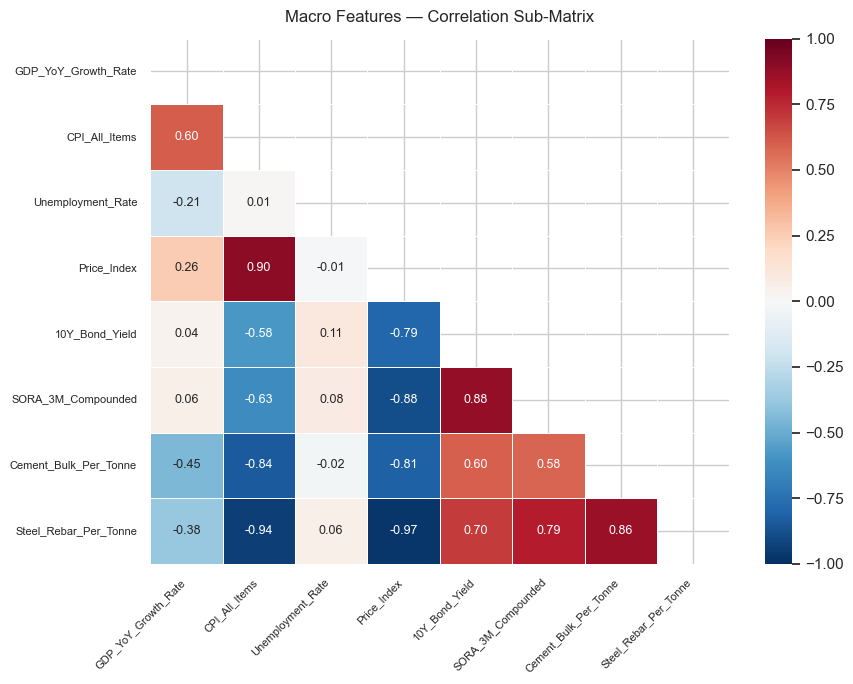

Within-group VIF (macro features only):


,Feature,VIF,Flag
0,Price_Index,88.13,HIGH
1,Steel_Rebar_Per_Tonne,50.34,HIGH
2,CPI_All_Items,45.85,HIGH
3,SORA_3M_Compounded,19.53,HIGH
4,GDP_YoY_Growth_Rate,6.97,WATCH
5,Cement_Bulk_Per_Tonne,5.84,WATCH
6,10Y_Bond_Yield,5.64,WATCH
7,Unemployment_Rate,1.89,OK



Macro features — correlation with target:
  +0.061  GDP_YoY_Growth_Rate
  +0.103  CPI_All_Items
  -0.004  Unemployment_Rate
  +0.099  Price_Index
  -0.062  10Y_Bond_Yield
  -0.080  SORA_3M_Compounded
  -0.072  Cement_Bulk_Per_Tonne
  -0.100  Steel_Rebar_Per_Tonne


In [7]:
macro_cols = [
    "GDP_YoY_Growth_Rate", "CPI_All_Items", "Unemployment_Rate",
    "Price_Index", "10Y_Bond_Yield", "SORA_3M_Compounded",
    "Cement_Bulk_Per_Tonne", "Steel_Rebar_Per_Tonne"
]

macro_corr = df[macro_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(macro_corr, dtype=bool))
sns.heatmap(macro_corr, mask=mask, annot=True, fmt=".2f",
            cmap="RdBu_r", vmin=-1, vmax=1,
            linewidths=0.5, linecolor="white",
            annot_kws={"size": 9}, ax=ax)
ax.set_title("Macro Features — Correlation Sub-Matrix", fontsize=12, pad=12)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# Within-group VIF
print("Within-group VIF (macro features only):")
display(compute_vif(df[macro_cols].dropna()))

# Correlation with target
print("\nMacro features — correlation with target:")
for col in macro_cols:
    r = df[col].corr(df[TARGET])
    print(f"  {r:+.3f}  {col}")

### 5d. Time Features — Excluded from Analysis

`Year`, `Month`, and `Quarter` are **not included as model features** — they serve solely as mapping keys to join macro indicators (GDP, CPI, SORA, etc.) onto transaction records. Including them would introduce artificial collinearity with the macro features they were used to derive.

In [8]:
print("Year, Month, Quarter excluded from feature set.")
print("These columns are mapping keys used to join macro indicators onto transactions.")
print("They carry no independent predictive signal and would inflate VIF artificially.")

Year, Month, Quarter excluded from feature set.
These columns are mapping keys used to join macro indicators onto transactions.
They carry no independent predictive signal and would inflate VIF artificially.


## 6. Iterative VIF Reduction

Remove the feature with the highest VIF at each step until all remaining features have VIF < 10.

In [9]:
remaining = FEATURE_COLS.copy()
removal_log = []
VIF_THRESHOLD = 10

iteration = 0
while True:
    vif_df = compute_vif(df[remaining].dropna())
    max_vif = vif_df.iloc[0]["VIF"]
    max_feat = vif_df.iloc[0]["Feature"]

    if max_vif <= VIF_THRESHOLD:
        break

    removal_log.append({
        "Iteration": iteration + 1,
        "Feature Removed": max_feat,
        "VIF at Removal": max_vif,
        "Features Remaining": len(remaining) - 1
    })
    remaining.remove(max_feat)
    iteration += 1

log_df = pd.DataFrame(removal_log)
print("=== Removal Log ===")
display(log_df)

print(f"\n=== Final Feature Set ({len(remaining)} features, all VIF < {VIF_THRESHOLD}) ===")
final_vif = compute_vif(df[remaining].dropna())
display(final_vif.style.apply(highlight_vif, axis=1))

print(f"\nFeatures removed: {[r['Feature Removed'] for r in removal_log]}")
print(f"Features kept:    {remaining}")

=== Removal Log ===


,Iteration,Feature Removed,VIF at Removal,Features Remaining
0,1,Price_Index,88.14,10
1,2,Steel_Rebar_Per_Tonne,38.14,9



=== Final Feature Set (9 features, all VIF < 10) ===


,Feature,VIF,Flag
0,CPI_All_Items,9.300000,WATCH
1,SORA_3M_Compounded,6.940000,WATCH
2,10Y_Bond_Yield,4.850000,OK
3,GDP_YoY_Growth_Rate,4.230000,OK
4,Cement_Bulk_Per_Tonne,3.740000,OK
5,Remaining_Lease_Years,3.070000,OK
6,Lease_Duration,3.010000,OK
7,Unemployment_Rate,1.360000,OK
8,Area (sqft),1.040000,OK



Features removed: ['Price_Index', 'Steel_Rebar_Per_Tonne']
Features kept:    ['Area (sqft)', 'Lease_Duration', 'Remaining_Lease_Years', 'GDP_YoY_Growth_Rate', 'CPI_All_Items', 'Unemployment_Rate', '10Y_Bond_Yield', 'SORA_3M_Compounded', 'Cement_Bulk_Per_Tonne']


## 7. Summary & Recommendations

In [10]:
dropped = [r["Feature Removed"] for r in removal_log]

print("=" * 60)
print("MULTICOLLINEARITY ANALYSIS — SUMMARY")
print("=" * 60)

print(f"\n[DROPPED] {len(dropped)} features removed (VIF > {VIF_THRESHOLD}):")
for f in dropped:
    print(f"  - {f}")

print(f"\n[KEPT] {len(remaining)} features (all VIF < {VIF_THRESHOLD}):")
for f in remaining:
    r = df[f].corr(df[TARGET])
    print(f"  - {f:<30}  target r = {r:+.3f}")

print("""
[NOTES]
1. Tree-based models (Random Forest, XGBoost) are robust to
   multicollinearity — the above removal applies primarily to
   linear/ridge/lasso regression models.

2. Remaining macro features still share low unique value counts
   (quarterly aggregates). If further reduction is needed,
   consider PCA on the macro block to create 1-2 components.

3. Spatial features (Postal Sector, Region, Planning Area) are
   categorical and not included in VIF — handle via encoding
   strategies (target encoding recommended for Planning Area).

[NEXT STEP]
→ Use the reduced feature set for linear model retraining
  and compare R² improvement vs original feature set.
""")

MULTICOLLINEARITY ANALYSIS — SUMMARY

[DROPPED] 2 features removed (VIF > 10):
  - Price_Index
  - Steel_Rebar_Per_Tonne

[KEPT] 9 features (all VIF < 10):
  - Area (sqft)                     target r = -0.377
  - Lease_Duration                  target r = +0.586
  - Remaining_Lease_Years           target r = +0.672
  - GDP_YoY_Growth_Rate             target r = +0.061
  - CPI_All_Items                   target r = +0.103
  - Unemployment_Rate               target r = -0.004
  - 10Y_Bond_Yield                  target r = -0.062
  - SORA_3M_Compounded              target r = -0.080
  - Cement_Bulk_Per_Tonne           target r = -0.072

[NOTES]
1. Tree-based models (Random Forest, XGBoost) are robust to
   multicollinearity — the above removal applies primarily to
   linear/ridge/lasso regression models.

2. Remaining macro features still share low unique value counts
   (quarterly aggregates). If further reduction is needed,
   consider PCA on the macro block to create 1-2 components.

